In [1]:
import ot
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
import math
import scipy
from scipy.spatial import cKDTree
from scipy import integrate
from scipy import interpolate
from scipy.spatial import Delaunay
from scipy.spatial import Voronoi
from itertools import product
import torch
torch.manual_seed(100000)
import torch.nn as nn
import torch.optim as optim
import pysindy as ps



/homes/yinonghyn/.local/lib/python3.10/site-packages/pysindy/feature_library/base.py:40: DeprecationWarning: Library ensembling is no longer performed by feature libraries.  Use EnsemblingOptimizer to fit an ensemble model.
  warnings.warn(


In [2]:
#settings
N = 5  # Number of variables
F = 8  # Forcing
start = F * np.ones(N)  # Initial state (equilibrium)
start[0] += 0.01  # Add small perturbation to the first variable
dt = 0.01
subset_size = 200#200#50#cell number#TODO: INCREASE
traj_length = int(1e6)#length of trajectory
noise_level = 0.2#.3
sample_size = int(5000)
slope = 0.05
sampling_time = 1
simulation_t = int(5e3)
epsilon = 1e-4
steps = 5#20
def L96(x, t):
    """Lorenz 96 model with constant forcing"""
    return (np.roll(x, -1) - np.roll(x, 2)) * np.roll(x, 1) - x + F 
def L96_vec_unforced(X):

    return (torch.roll(X, shifts=-1, dims=1) - torch.roll(X, shifts=2, dims=1)) * torch.roll(X, shifts=1, dims=1) - X 

t = np.arange(0.0, traj_length*dt, dt)

def invariant_measure(matrix):
    N = len(matrix)
    rhs = (-1) * (epsilon/N) * torch.ones(N)
    rho = torch.linalg.solve(((1 - epsilon) * matrix - torch.eye(N)),rhs)
    return rho

In [3]:
trajectory_clean = scipy.integrate.odeint(L96, start, t)

In [4]:
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,5)))#loooooooong trajectory
trajectory = trajectory[int(1e3):][::sampling_time]

#uniformly random data
trajectory = trajectory_clean + np.random.normal(0,noise_level,((traj_length,5)))#loooooooong trajectory
trajectory = trajectory[int(1e3):]
rand_idxs = np.random.choice(len(trajectory), size=sample_size, replace=False)
observed = trajectory[rand_idxs]
randpts = torch.tensor(trajectory[rand_idxs],dtype = torch.float)
Trandpts = torch.tensor(trajectory[rand_idxs+steps],dtype = torch.float)

#normalization
M_scale = torch.max(torch.abs(randpts))
randpts /= M_scale
Trandpts /= M_scale

#Voronoi cell center
Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_

tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)

relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)


def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    mat = (mat.T)/mat.sum(dim = 1)
    return mat
U_true = Ulam(randpts,Trandpts)
im_true = invariant_measure(U_true)
im_true_np = im_true.detach().cpu().numpy()
class W2Loss(torch.autograd.Function):
    @staticmethod
    def forward(ctx, im_net):
        im_net_np = im_net.detach().numpy()
        im_net_np /= np.sum(im_net_np)
        im_true_np_norm = im_true_np / np.sum(im_true_np)  # assumes im_true_np is a global or passed variable

    # Define cost matrix##LOCATION OF CELL CENTERS
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), 
                        np.arange(subset_size).reshape(-1, 1))
        _, log = ot.emd(im_true_np_norm, im_net_np, costM, log=True)
        cost,grad = log['cost'],log["v"]
        loss = np.sum(cost)
        grad_tensor = torch.tensor(grad, dtype=im_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,)

/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


In [5]:
# plt.scatter(randpts[:,0],randpts[:,1],s = 1)
# plt.scatter(Voronoi_centers[:,0],Voronoi_centers[:,1])

In [23]:

torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 1))##CHANGED

# net1 = nn.Sequential(
#             nn.Linear(5, 100),
#             nn.Tanh(),
#             nn.Linear(100, 100),
#             nn.Tanh(),
#             nn.Linear(100, 100),
#             nn.Tanh(),
#             nn.Linear(100, 1))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
N_iters = 50000

net1.train()
loss1 = []
#invert_variables = [0]
net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field = L96_vec_unforced(net1_randpts*M_scale)/M_scale
    V_field += net1(net1_randpts)
    net1_randpts = net1_randpts+dt* V_field
U_net = Ulam(randpts,net1_randpts)
im_net = invariant_measure(U_net)
initial_L1 =  torch.linalg.norm(im_net - im_true, dtype=torch.float32)

Iteration 0, Loss(Ours): 6.923692126292735e-05


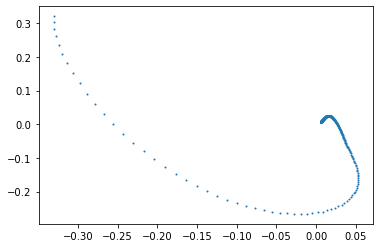

Iteration 500, Loss(Ours): 1.0619355634844396e-05
Early stopping at iteration 500, Loss: 1.0619355634844396e-05


In [24]:

for i in range(N_iters):
    optimizer1.zero_grad()
    net1_randpts = randpts
    for _ in range(steps):
        V_field = L96_vec_unforced(net1_randpts*M_scale)/M_scale
        V_field += net1(net1_randpts)
        net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts,net1_randpts)
    im_net = invariant_measure(U_net)
 #   L1 = torch.mean((net1_randpts - Trandpts)**2)
   # L1 = torch.linalg.matrix_norm(U_net - U_true,ord = 'fro')
    L1 = torch.linalg.norm(im_net - im_true, dtype=torch.float32)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Ours): {L1.item()}')#, Loss(Pointwise): {L2.item()}')
            if L1.item() < 0.25  * initial_L1:
                print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
                break
        
    # Visualization every 500 iterations
    if i % 2000 == 0:
        x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, N)
        # x2 = x1
        vals1= []
        for _ in range(int(1e3)):
            V_field = L96_vec_unforced(x1*M_scale)/M_scale
            V_field += net1(x1)
            x1 = x1+dt* V_field
                
            vals1.append(x1.detach().numpy().flatten())
            # x2 = net2(x2)
            # vals2.append(x2.detach().numpy().flatten())
        
        vals1= np.array(vals1)
        plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
        plt.show()

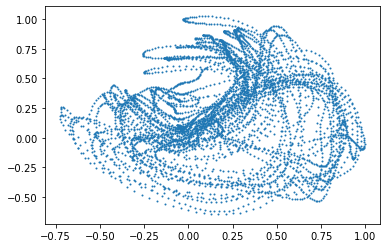

In [25]:
x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, N)
vals1 = [x1.detach().numpy().flatten()]
for _ in range(simulation_t-1):
    V_field = L96_vec_unforced(x1*M_scale)/M_scale
    V_field += net1(x1)
    x1 = x1+dt* V_field
    vals1.append(x1.detach().numpy().flatten())
vals1 = np.array(vals1)
plt.scatter(vals1[:, 0], vals1[:, 1], s=1)
#plt.ylim([-1.5,1.5])
plt.show()

In [9]:
# x1 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
# vals1 = [x1.detach().numpy().flatten()]
# for _ in range(simulation_t-1):
#     for i in range(steps):
#         V_field = L96_vec(x1*M_scale)/M_scale
#         V_field[:,invert_variables] = net1(x1)[:,invert_variables]
#         x1 = x1+dt* V_field
#     vals1.append(x1.detach().numpy().flatten())
# vals1 = np.array(vals1)
# plt.scatter(vals1[:, 0], vals1[:, 1], s=1)

# plt.show()

In [10]:
#plt.plot(vals1[:, 0], vals1[:, 1])

In [26]:

# net2 = nn.Sequential(
#             nn.Linear(5, 100),
#             nn.Tanh(),
#             nn.Linear(100, 100),
#             nn.Tanh(),
#             nn.Linear(100, 100),
#             nn.Tanh(),
#             nn.Linear(100, 1))
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(5, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 1))##CHANGE from 100 to 200?

optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
net2.train()


loss2 = []
net2_randpts = randpts.clone()  # safe copy, avoid modifying original tensor
for _ in range(steps):
    V_field2 = L96_vec_unforced(net2_randpts*M_scale)/M_scale
    V_field2 += net2(net2_randpts)
    net2_randpts = net2_randpts+dt* V_field2
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)

Iteration 0, Loss(Pointwise): 0.00264400034211576


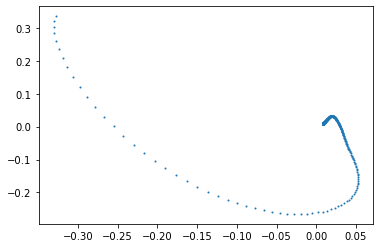

Iteration 500, Loss(Pointwise): 0.0007450737757608294
Iteration 1000, Loss(Pointwise): 0.0007447389070875943
Iteration 1500, Loss(Pointwise): 0.0007433476275764406
Iteration 2000, Loss(Pointwise): 0.0007411535480059683
Iteration 2500, Loss(Pointwise): 0.0007405654760077596
Iteration 3000, Loss(Pointwise): 0.0007396265282295644
Iteration 3500, Loss(Pointwise): 0.0007388625526800752
Iteration 4000, Loss(Pointwise): 0.0007380923489108682
Iteration 4500, Loss(Pointwise): 0.0007366911158896983
Iteration 5000, Loss(Pointwise): 0.0007344785844907165


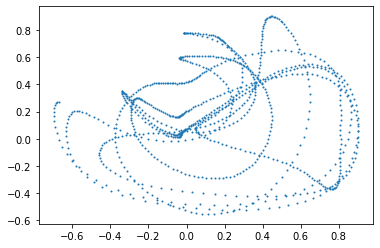

Iteration 5500, Loss(Pointwise): 0.0007324045291170478
Iteration 6000, Loss(Pointwise): 0.0007300598081201315
Iteration 6500, Loss(Pointwise): 0.000728075799997896
Iteration 7000, Loss(Pointwise): 0.0007258257828652859
Iteration 7500, Loss(Pointwise): 0.0007233643555082381
Iteration 8000, Loss(Pointwise): 0.0007208218448795378
Iteration 8500, Loss(Pointwise): 0.0007183254929259419
Iteration 9000, Loss(Pointwise): 0.0007157784420996904
Iteration 9500, Loss(Pointwise): 0.000712723471224308
Iteration 10000, Loss(Pointwise): 0.0007097154739312828


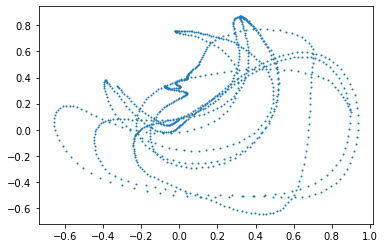

Iteration 10500, Loss(Pointwise): 0.0007062115473672748
Iteration 11000, Loss(Pointwise): 0.0007030137348920107
Iteration 11500, Loss(Pointwise): 0.0006998165627010167
Iteration 12000, Loss(Pointwise): 0.0006965348147787154
Iteration 12500, Loss(Pointwise): 0.0006931564421392977
Iteration 13000, Loss(Pointwise): 0.000689747161231935
Iteration 13500, Loss(Pointwise): 0.0006872090743854642
Iteration 14000, Loss(Pointwise): 0.0006830578786320984
Iteration 14500, Loss(Pointwise): 0.0006797715905122459
Iteration 15000, Loss(Pointwise): 0.0006810427294112742


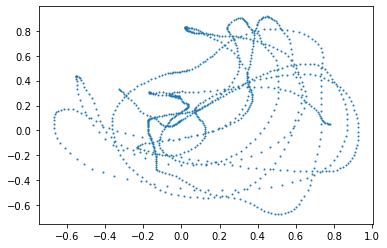

Iteration 15500, Loss(Pointwise): 0.0006732710753567517
Iteration 16000, Loss(Pointwise): 0.0006700956728309393
Iteration 16500, Loss(Pointwise): 0.0006668459391221404
Iteration 17000, Loss(Pointwise): 0.0006637281621806324
Iteration 17500, Loss(Pointwise): 0.0006606485694646835
Early stopping at iteration 17500, Loss: 0.0006606485694646835


In [27]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()
    # optimizer2.zero_grad()
    
    # Update for net1 (Ulam)
    # net1_randpts = net1(randpts) #parametrize the map

    
    net2_randpts = randpts
    for _ in range(steps):
        V_field2 = L96_vec_unforced(net2_randpts*M_scale)/M_scale
        V_field2 += net2(net2_randpts)
        net2_randpts = net2_randpts+dt* V_field2

    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())
    with torch.no_grad():
        if i % 500 == 0:
            print(f'Iteration {i}, Loss(Pointwise): {L2.item()}')
            if L2.item() < 0.25 * initial_L2:
                print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
                break
        
    # Visualization
    if i % 5000 == 0:
        x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
        vals2 = [x2.detach().numpy().flatten()]
        for _ in range(int(1e3)):
            V_field2 = L96_vec_unforced(x2*M_scale)/M_scale
            V_field2 += net2(x2)
            x2 = x2+dt* V_field2
            vals2.append(x2.detach().numpy().flatten())
        vals2 = np.array(vals2)
        plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
        plt.show()

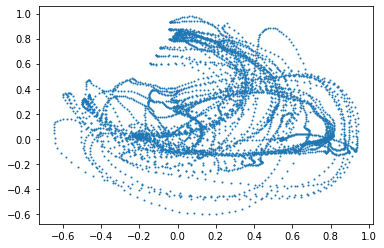

In [28]:
x2 = torch.tensor(randpts[0], dtype=torch.float).reshape(1, 5)
vals2 = [x2.detach().numpy().flatten()]
for _ in range(simulation_t-1):
    V_field2 = L96_vec_unforced(x2*M_scale)/M_scale
    V_field2 += net2(x2)
    x2 = x2+dt* V_field2
    vals2.append(x2.detach().numpy().flatten())
vals2 = np.array(vals2)
plt.scatter(vals2[:, 0], vals2[:, 1], s=1)
plt.show()

In [29]:
GT = scipy.integrate.odeint(L96, M_scale*randpts[0], np.arange(0.0, simulation_t*dt, dt))

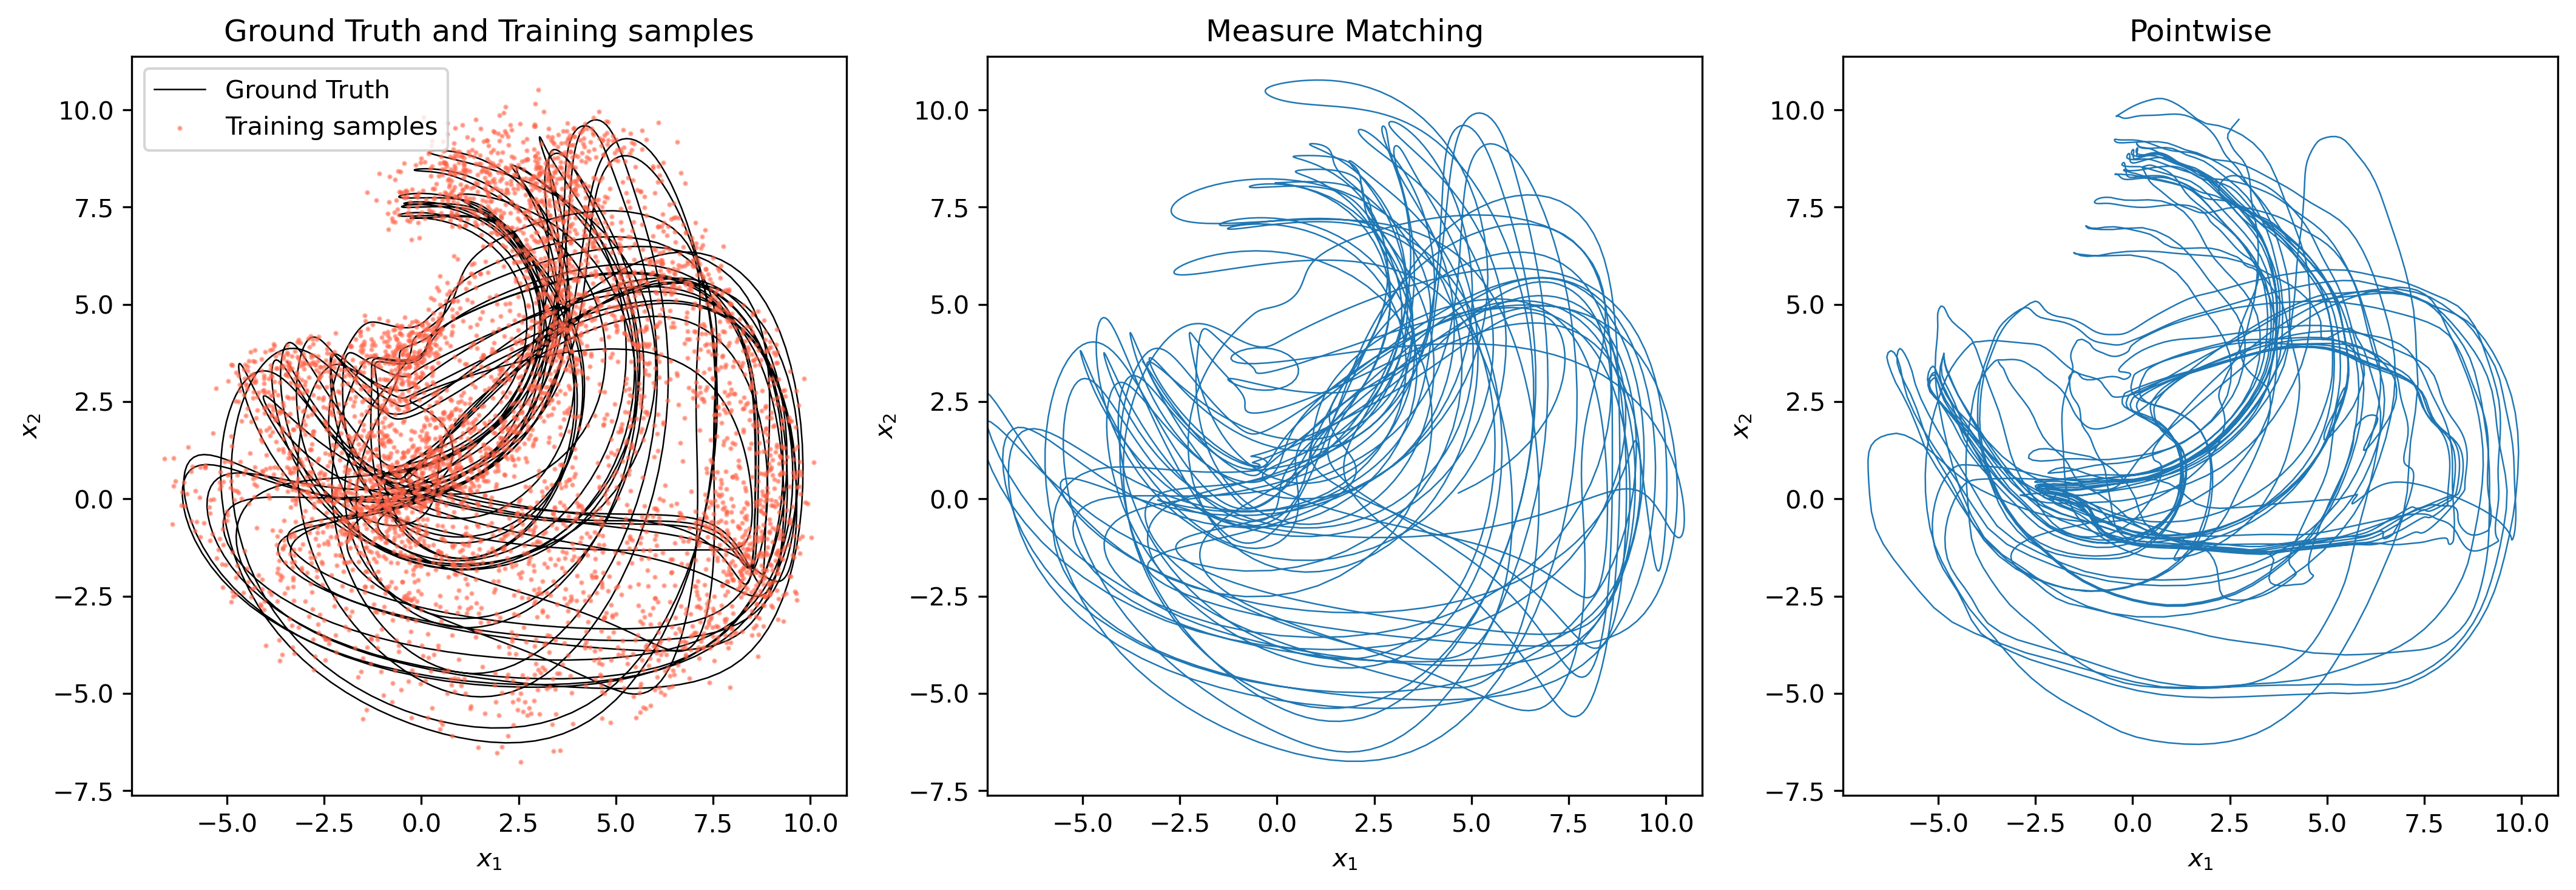

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi = 300)

axes[1].plot(M_scale * vals1[:, 0], M_scale * vals1[:, 1], linewidth=0.6)
axes[1].set_title('Measure Matching')

# Plot vals_ode (neural ODE results)
axes[2].plot(M_scale * vals2[:, 0], M_scale * vals2[:, 1], linewidth=0.6)
axes[2].set_title('Pointwise')

# Plot ground truth trajectory
axes[0].plot(GT[:, 0], GT[:, 1], label="Ground Truth", linewidth=0.6, zorder=1, c = "black")
axes[0].scatter(M_scale * randpts[:, 0], M_scale * randpts[:, 1], s=1, c="tomato", alpha = 0.5,
                label="Training samples", zorder=2)
axes[0].set_title('Ground Truth and Training samples')
axes[0].legend(loc='upper left')

# Set axis labels and layout
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()


for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')

#fig.text(0.04, 0.5, 'Lorenz-96', va='center', rotation='vertical', fontsize=14)
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

In [ ]:
#plt.plot(vals2[:, 0], vals2[:, 1])

In [35]:
n = simulation_t
subGT, subvals1, subvals2 = GT, np.array(M_scale * vals1), np.array(M_scale * vals2)

a, b = np.ones((n,)) / n, np.ones((n,)) / n
M1, M2 = ot.dist(subGT, subvals1),ot.dist(subGT, subvals2)
_,G01 = ot.emd(a, b, M1,log = 'true')
_,G02 = ot.emd(a, b, M2,log = 'true')
cost1W,cost2W = (G01['cost'])**(1/2),(G02['cost'])**(1/2)
print(cost1W, cost2W)

2.6283940344273655 3.2637767875416506


In [ ]:
# costs1W, costs2W = [cost1W], [cost2W] 

costs1W.append(cost1W)
costs2W.append(cost2W)
costs1W, costs2W

In [36]:
GTpts = torch.tensor((GT/M_scale)[:-steps],dtype = torch.float)
GTTpts = GT[steps:]

net1pts,net2pts = GTpts, GTpts
for i in range(steps):
    Vf1,Vf2 = net1(net1pts),net2(net2pts)
    net1pts,net2pts = net1pts+dt*Vf1,net2pts+dt*Vf2
print((np.mean((np.array(M_scale)*net1pts.detach().numpy()-GTTpts)**2))**(1/2))
print((np.mean((np.array(M_scale)*net2pts.detach().numpy()-GTTpts)**2))**(1/2))

1.0425233516684111
1.027615102365627
